In [1]:
# Libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import openpyxl
import datetime as dt

In [2]:
import VPP_model_household as house
import VPP_model_NEM as nem
import VPP_origin as origin

In [17]:
# Data stuff
# Import one of the households for individual data from excel
print("Importing individual data...")
household_num = 137
fname = "dataOut/origin_vpp_{}.xlsx".format(household_num)
df_ind_sc = pd.read_excel(fname)
fname = "dataOut/self_consume_{}.xlsx".format(household_num)
df_ind_vpp = pd.read_excel(fname)
print("Individual data imported.")

Importing individual data...
Individual data imported.


In [6]:
print("Importing aggregate data...")
# Import the time series aggregate data from excel
df_agg_time = pd.read_excel("annual_total_by_time.xlsx")
t = pd.to_datetime(df_agg_time.iloc[:,0])
df_agg_time = df_agg_time.iloc[:,1:]
df_agg_time.index = t

# Import the totals by household for self consumption
df_agg_tot_sc = pd.read_excel("self_consumption_total_by_household.xlsx")

# Import the totals by household for origin VPP
df_agg_tot_vpp = pd.read_excel("vpp_total_by_household.xlsx")
print("Aggregate data imported.")

Importing aggregate data...
Aggregate data imported.


107 days, 0:00:00
Index([ 0.5,  1.0,  1.5,  2.0,  2.5,  3.0,  3.5,  4.0,  4.5,  5.0,  5.5,  6.0,
        6.5,  7.0,  7.5,  8.0,  8.5,  9.0,  9.5, 10.0, 10.5, 11.0, 11.5, 12.0,
       12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 16.5, 17.0, 17.5, 18.0,
       18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5, 24.0],
      dtype='float64')


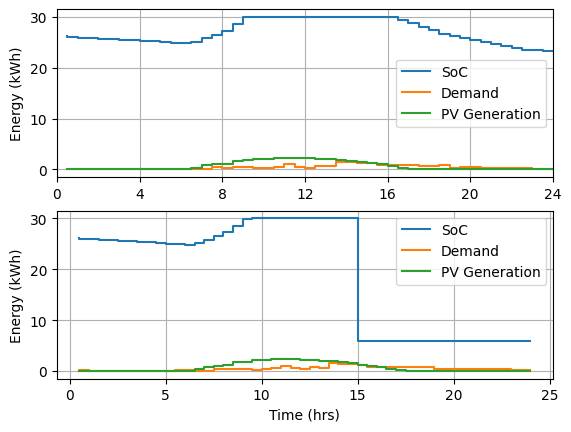

In [140]:
# Individual data plots

# Get times for grid event
# Grid event at 16/10/2012  3:30:00 PM
t_start = dt.datetime(2012, 7, 1, 0, 30, 0)
t_event = dt.datetime(2012, 10, 16, 0, 30, 0)
diff = t_event - t_start
print(diff)
i_start = int(2*divmod(diff.total_seconds(), 3600)[0])
i_end = int(i_start+48)
t_hrs= (dat_24hr.index-i_start)/2+0.5
print(t_hrs)

plt.figure()
# Plot self consumption
ax = plt.subplot(2,1,2)
ax.grid()
dat_24hr_sc = df_ind_sc.iloc[i_start:i_end,:]

# Data: Self Consumption
# Battery SoC
soc = dat_24hr_sc['SoC (kWh)']
# Load
load = dat_24hr_sc['load']
# PV Generation
pv = dat_24hr_sc['PV']


# Plot
ax.step(t_hrs, soc, label = "SoC")
ax.step(t_hrs, load, label = "Demand")
ax.step(t_hrs, pv, label = "PV Generation")

# Tidy up the plot
ax.set_xlabel("Time (hrs)")
ax.set_ylabel("Energy (kWh)")
ax.legend()

# Plot VPP
ax = plt.subplot(2,1,1)
dat_24hr_vpp = df_ind_vpp.iloc[i_start:i_end,:]

# Data: subplot 2
# Battery SoC
soc = dat_24hr_vpp['SoC (kWh)']
# Load
load = dat_24hr_vpp['load']
# PV Generation
pv = dat_24hr_vpp['PV']

# Plot
ax.step(t_hrs, soc, label = "SoC")
ax.step(t_hrs, load, label = "Demand")
ax.step(t_hrs, pv, label = "PV Generation")

ax.grid()
ax.set_ylabel("Energy (kWh)")
ax.set_xlim([0, 24])
ax.set_xticks(np.arange(0,25,4))
ax.legend()

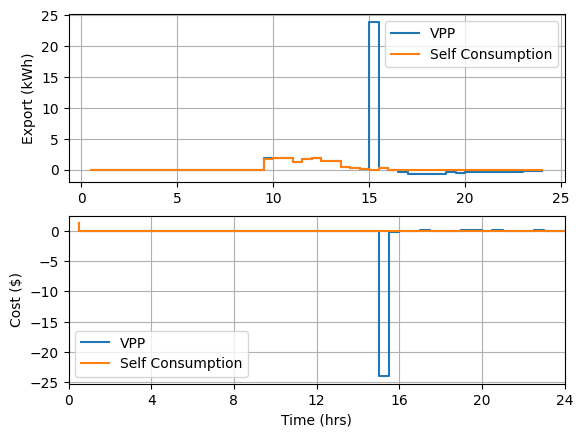

In [143]:
# Data subplot 2
plt.figure()

# Export/Import: PV and battery
ax = plt.subplot(2,1,1)
ax.grid()
# Plot for self consumption
# Export
exp = dat_24hr_sc['Export (kWh)'] - dat_24hr_sc['Import (kWh)']
ax.step(t_hrs, exp, label = "VPP")
exp = dat_24hr_vpp['Export (kWh)'] - dat_24hr_vpp['Import (kWh)']
ax.step(t_hrs, exp, label = "Self Consumption")
ax.set_ylabel("Export (kWh)")
ax.legend()
# Plot
ax = plt.subplot(2,1,2)
ax.grid()
#spot = dat_24hr_sc['Spot Price ($/kWh)']
#ax.step(t_hrs, spot, label = "Spot Price")
bill = -dat_24hr_sc['Total Profit ($)']
ax.step(t_hrs, bill, label = "VPP")
bill = -dat_24hr_vpp['Total Profit ($)']
ax.step(t_hrs, bill, label = "Self Consumption")
ax.set_ylabel("Cost ($)")
ax.legend()

ax.set_xlabel("Time (hrs)")
ax.set_xlim([0, 24])
ax.set_xticks(np.arange(0,25,4))

# Bill cost
# Spot price

# During grid event 
# Same plots as above

# Plot battery SoC over time

Text(0.5, 0, 'Time (hrs)')

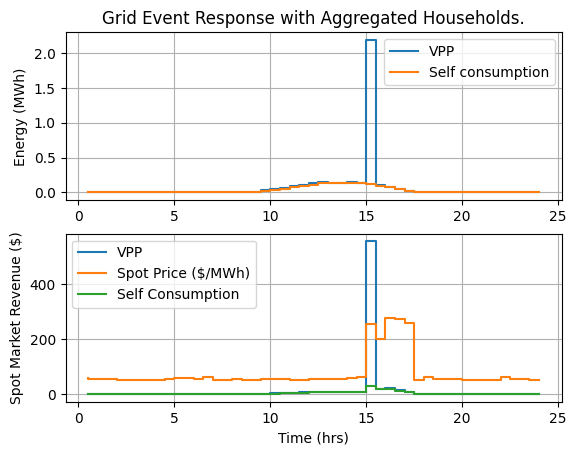

In [121]:
# Aggregate data plots - Totals by time
#print(df_agg_time)

dat_agg_24hr = df_agg_time.iloc[i_start:i_end,:]

# Do plots for above but show aggregate response during grid event

# Show annual response and price spikes with grid event threshold

spot_price = dat_24hr_sc['Spot Price ($/kWh)']

plt.figure()

ax = plt.subplot(2,1,1)
ax.set_title("Grid Event Response with Aggregated Households.")
ax.grid()

exp_vpp = dat_agg_24hr['VPP Export (kWh)']
ax.step(t_hrs, exp_vpp/1000, label = "VPP")
exp_sc = dat_agg_24hr['Self Consumption Export (kWh)']
ax.step(t_hrs, exp_sc/1000, label = "Self consumption")

ax.legend()


# Tidy up the plot

ax.set_ylabel("Energy (MWh)")

# Now do pricing
ax = plt.subplot(2,1,2)
ax.grid()

spot_profit_sc = np.zeros(len(spot_price))
spot_profit_vpp = np.zeros(len(spot_price))
for i in range(0, len(spot_price)):
    spot_profit_sc[i] = spot_price.iloc[i]*exp_sc.iloc[i]
    spot_profit_vpp[i] = spot_price.iloc[i]*exp_vpp.iloc[i]


plt.step(t_hrs, spot_profit_vpp, label = "VPP")
plt.step(t_hrs, spot_price*1000, label = "Spot Price ($/MWh)")
plt.step(t_hrs, spot_profit_sc, label = "Self Consumption")

ax.legend()
ax.set_ylabel("Spot Market Revenue ($)")
ax.set_xlabel("Time (hrs)")

Text(0.5, 0, 'Time (hrs)')

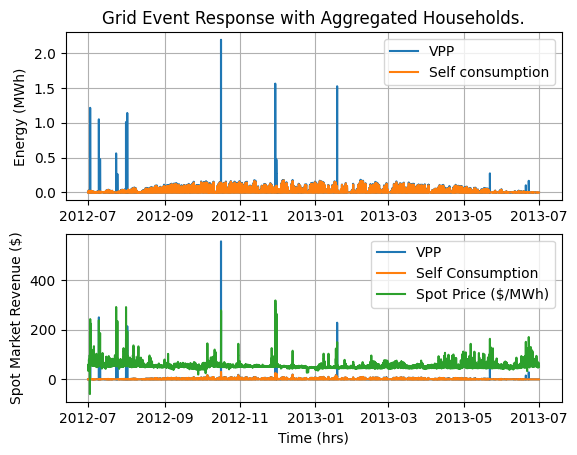

In [120]:
# Aggregate data plots - Totals by time
#print(df_agg_time)

# Do plots for above but show aggregate response during grid event

# Show annual response and price spikes with grid event threshold

spot_price = df_ind_sc['Spot Price ($/kWh)']

t = df_agg_time.index

plt.figure()

ax = plt.subplot(2,1,1)
ax.set_title("Grid Event Response with Aggregated Households.")
ax.grid()

exp_vpp = df_agg_time['VPP Export (kWh)']
ax.step(t, exp_vpp/1000, label = "VPP")
exp_sc = df_agg_time['Self Consumption Export (kWh)']
ax.step(t, exp_sc/1000, label = "Self consumption")

ax.legend()


# Tidy up the plot

ax.set_ylabel("Energy (MWh)")

# Now do pricing
ax = plt.subplot(2,1,2)
ax.grid()

spot_profit_sc = np.zeros(len(spot_price))
spot_profit_vpp = np.zeros(len(spot_price))
for i in range(0, len(spot_price)):
    spot_profit_sc[i] = spot_price.iloc[i]*exp_sc.iloc[i]
    spot_profit_vpp[i] = spot_price.iloc[i]*exp_vpp.iloc[i]


plt.step(t, spot_profit_vpp, label = "VPP")
plt.step(t, spot_price*1000, label = "Spot Price ($/MWh)")
plt.step(t, spot_profit_sc, label = "Self Consumption")

ax.legend()
ax.set_ylabel("Spot Market Revenue ($)")
ax.set_xlabel("Time (hrs)")

(array([17., 14.,  8.,  4.,  5.,  4.,  7.,  7.,  6.,  6.,  3.,  1.,  1.,
         1.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.]),
 array([ 208.54106729,  235.88484295,  263.22861861,  290.57239428,
         317.91616994,  345.2599456 ,  372.60372127,  399.94749693,
         427.2912726 ,  454.63504826,  481.97882392,  509.32259959,
         536.66637525,  564.01015092,  591.35392658,  618.69770224,
         646.04147791,  673.38525357,  700.72902923,  728.0728049 ,
         755.41658056,  782.76035623,  810.10413189,  837.44790755,
         864.79168322,  892.13545888,  919.47923454,  946.82301021,
         974.16678587, 1001.51056154, 1028.8543372 ]),
 <BarContainer object of 30 artists>)

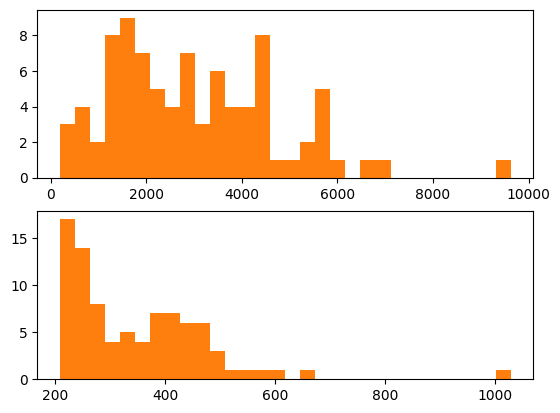

In [138]:
# Aggregate data plots - Totals by household
#print(df_agg_tot_sc)
#print(df_agg_tot_vpp)

# Histograms
plt.figure()
ax = plt.subplot(2,1,1)

export_sc = df_agg_tot_sc['Export (kWh)']
profit_sc = df_agg_tot_sc['Profit (kWh)']
spot_profit_sc = df_agg_tot_sc['Spot Profit (kWh)']

export_vpp = df_agg_tot_vpp['Export (kWh)']
profit_vpp = df_agg_tot_vpp['Profit (kWh)']
spot_profit_vpp = df_agg_tot_vpp['Spot Profit (kWh)']

ax.hist(export_sc, bins =30, label = "Self Consumption")
ax.hist(export_vpp, bins = 30, label = "VPP")
ax = plt.subplot(2,1,2)
ax.hist(-profit_sc, bins =30, label = "Self Consumption")
ax.hist(-profit_vpp, bins = 30, label = "VPP")

# Bill price: Plot self consumption and VPP on same graph

# Spot earnings: Plot self consumption and VPP on same graph